## SUPERVISED LEARNING → CLASSIFICATION

### Classification Algorithms
- KNN (K-Nearest Neighbors)
- Naive Bayes (NB)
- Decision Tree (DT)

---

## ENSEMBLE LEARNING

**Ensemble Learning** means combining multiple ML models to make a better prediction.

### Multiple Tree Models

There are mainly **2 types of ensemble techniques**:

### 1. BAGGING
**Bagging = Bootstrap Aggregation**

- Multiple models are trained **independently and in parallel**.
- Each model is trained using different samples of the dataset.
- The predictions from all models are combined to make the final prediction.

**Example: Random Forest**

```text
Tree 1 ──┐
Tree 2 ──┤
Tree 3 ──┤ → Combined Prediction → Final Output
Tree 4 ──┘      


## 2. BOOSTING

- Models are trained **one after another**.
- Each new model focuses on the **errors of the previous model**.
- The models are combined to make the final prediction.

    Model 1 → Errors → Model 2 → Errors → Model 3 → Final Prediction

### Types of Boosting

- **AdaBoost** → Focuses more on incorrectly classified data.
- **Gradient Boosting** → Tries to reduce previous errors.
- **XGBoost** → Optimized and efficient version of Gradient Boosting.

**Simple meaning:** Models learn from previous errors and improve step by step.


In [89]:
import pandas as pd
df=pd.read_csv("/content/IRIS.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [90]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [91]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [93]:
df.duplicated().sum()

np.int64(3)

In [94]:
df=df.drop_duplicates()

In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [97]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [98]:
for i in df.columns:
  print(i)
  print(df[i].unique())
  print("*"*50)

sepal_length
[5.1 4.9 4.7 4.6 5.  5.4 4.4 4.8 4.3 5.8 5.7 5.2 5.5 4.5 5.3 7.  6.4 6.9
 6.5 6.3 6.6 5.9 6.  6.1 5.6 6.7 6.2 6.8 7.1 7.6 7.3 7.2 7.7 7.4 7.9]
**************************************************
sepal_width
[3.5 3.  3.2 3.1 3.6 3.9 3.4 2.9 3.7 4.  4.4 3.8 3.3 4.1 4.2 2.3 2.8 2.4
 2.7 2.  2.2 2.5 2.6]
**************************************************
petal_length
[1.4 1.3 1.5 1.7 1.6 1.1 1.2 1.  1.9 4.7 4.5 4.9 4.  4.6 3.3 3.9 3.5 4.2
 3.6 4.4 4.1 4.8 4.3 5.  3.8 3.7 5.1 3.  6.  5.9 5.6 5.8 6.6 6.3 6.1 5.3
 5.5 6.7 6.9 5.7 6.4 5.4 5.2]
**************************************************
petal_width
[0.2 0.4 0.3 0.1 0.5 0.6 1.4 1.5 1.3 1.6 1.  1.1 1.8 1.2 1.7 2.5 1.9 2.1
 2.2 2.  2.4 2.3]
**************************************************
species
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
**************************************************


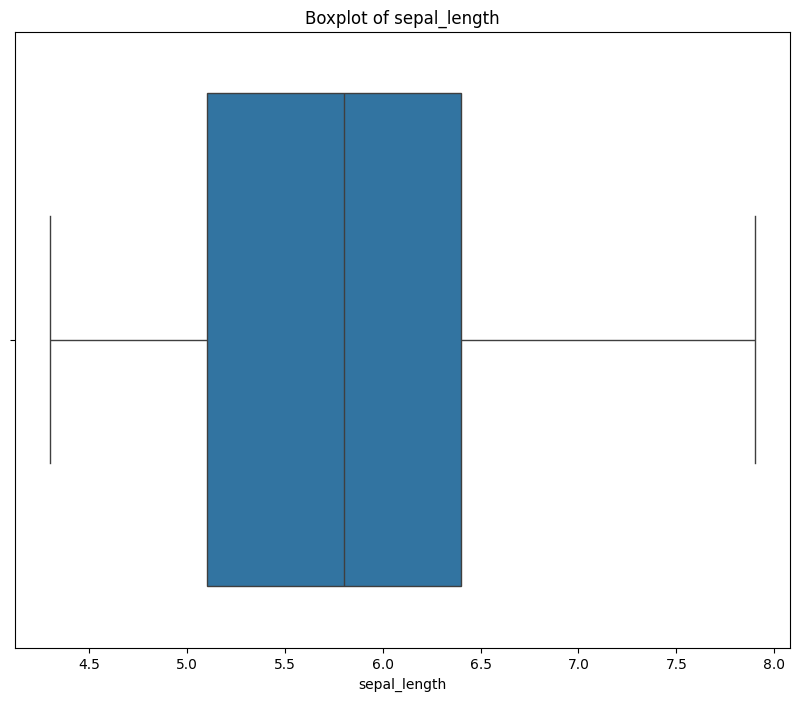

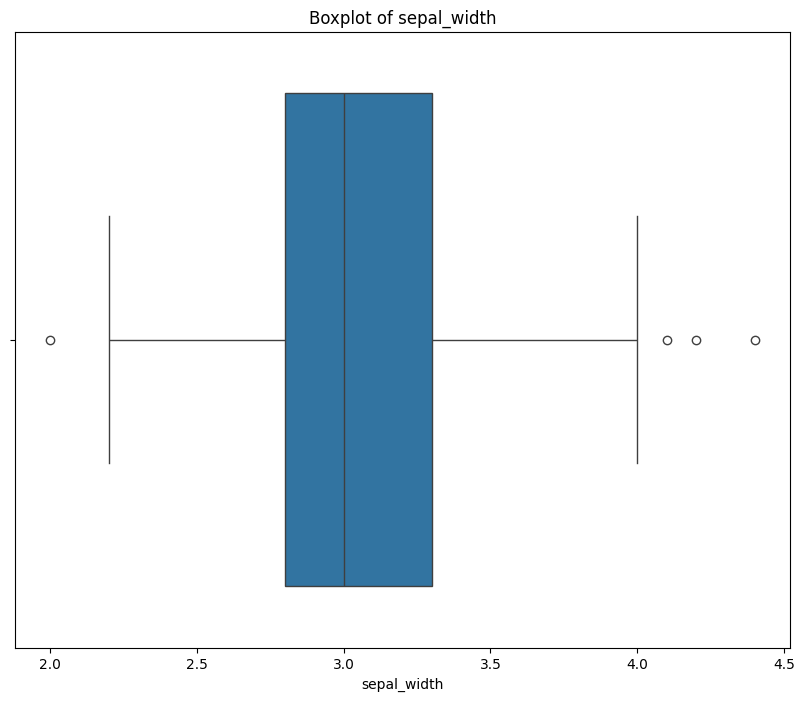

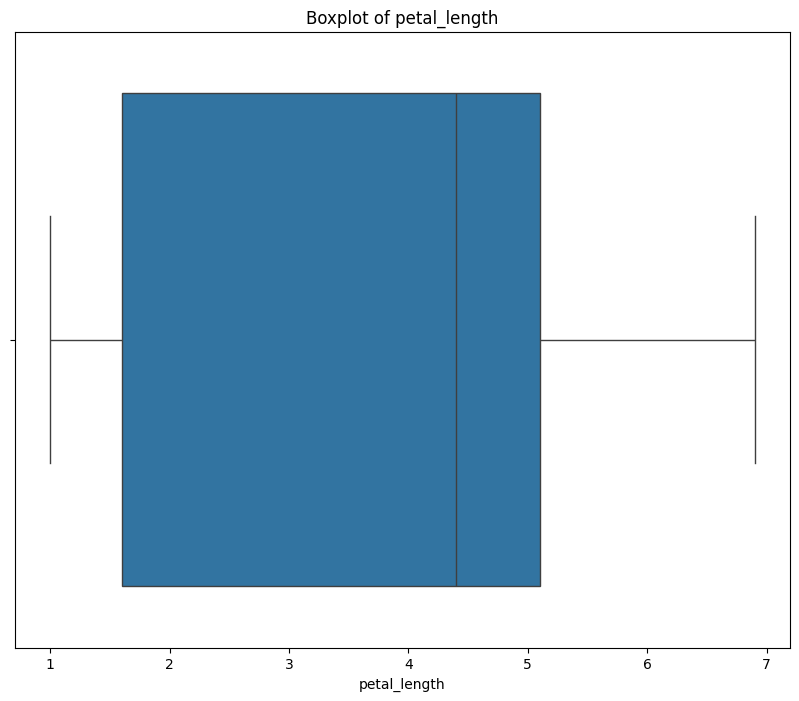

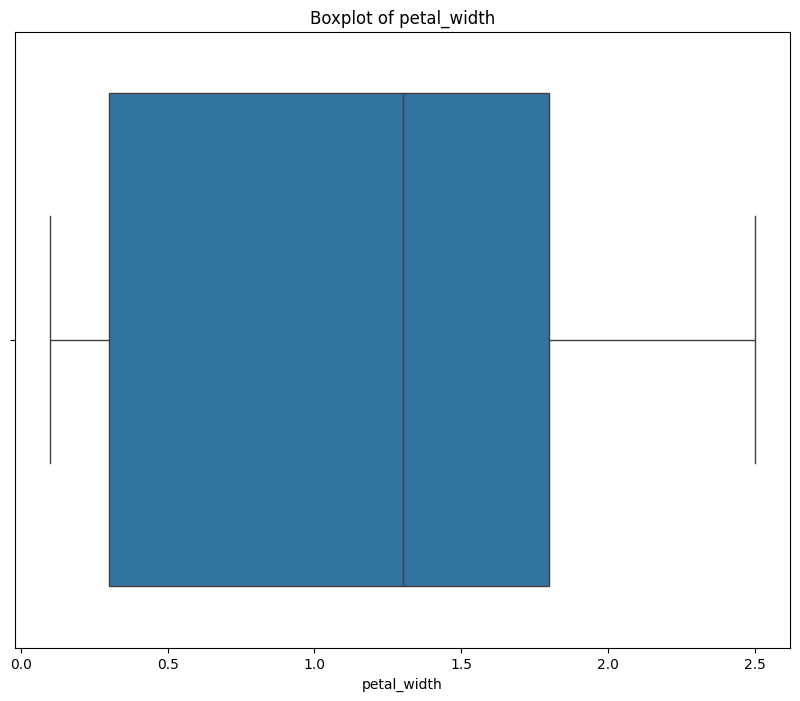

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.drop(columns="species").columns:
  plt.figure(figsize=(10,8))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

In [100]:
col = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i in col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[i] >= lower) & (df[i] <= upper)]

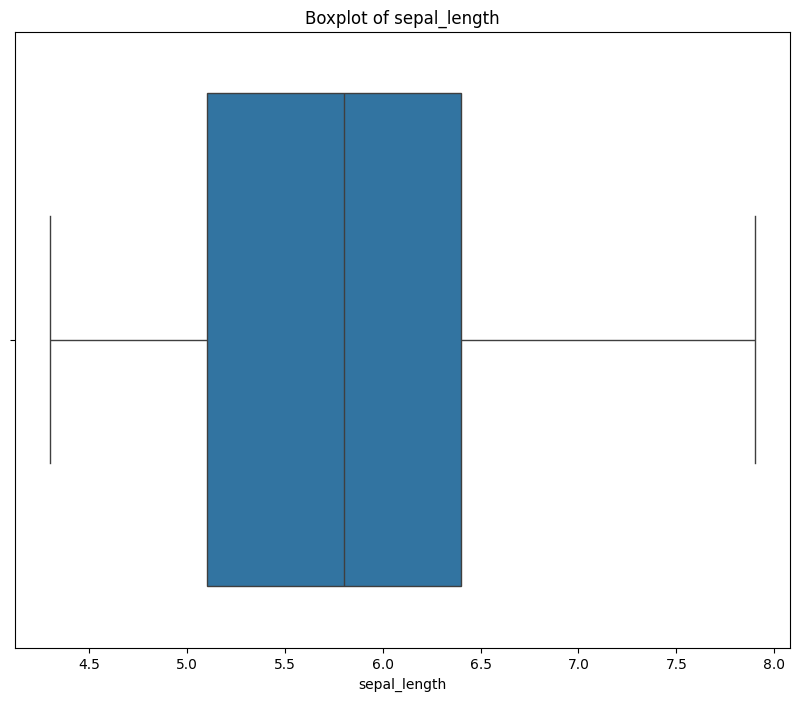

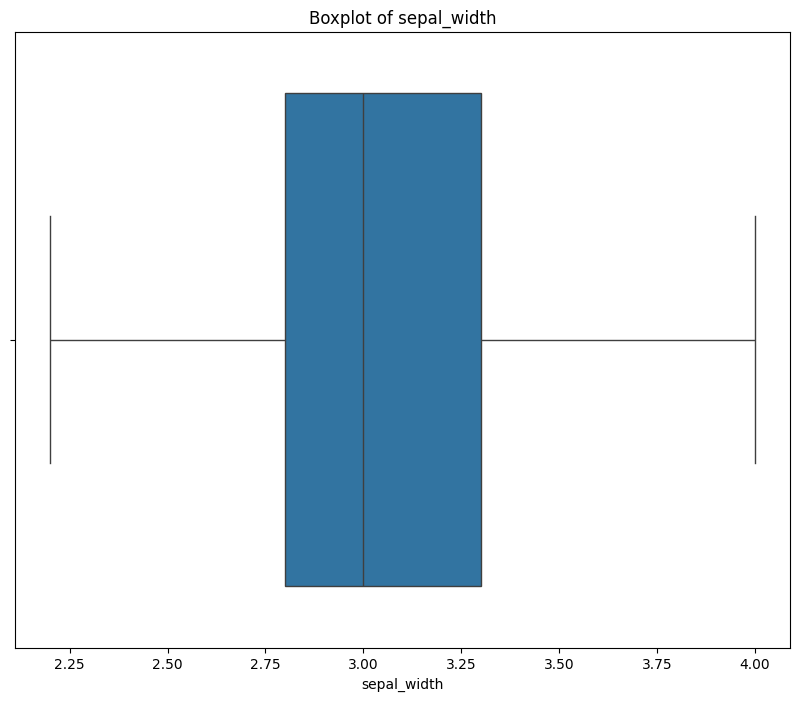

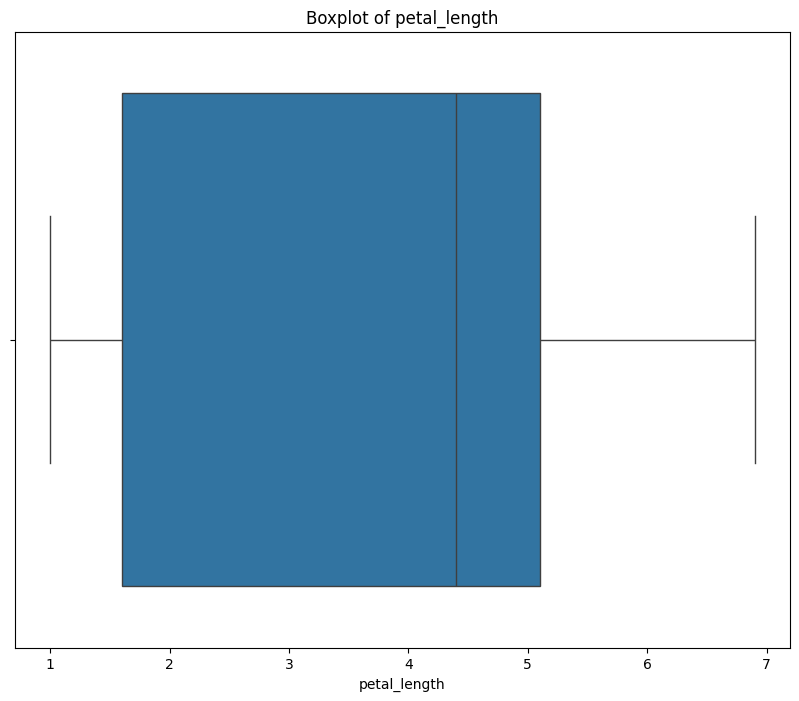

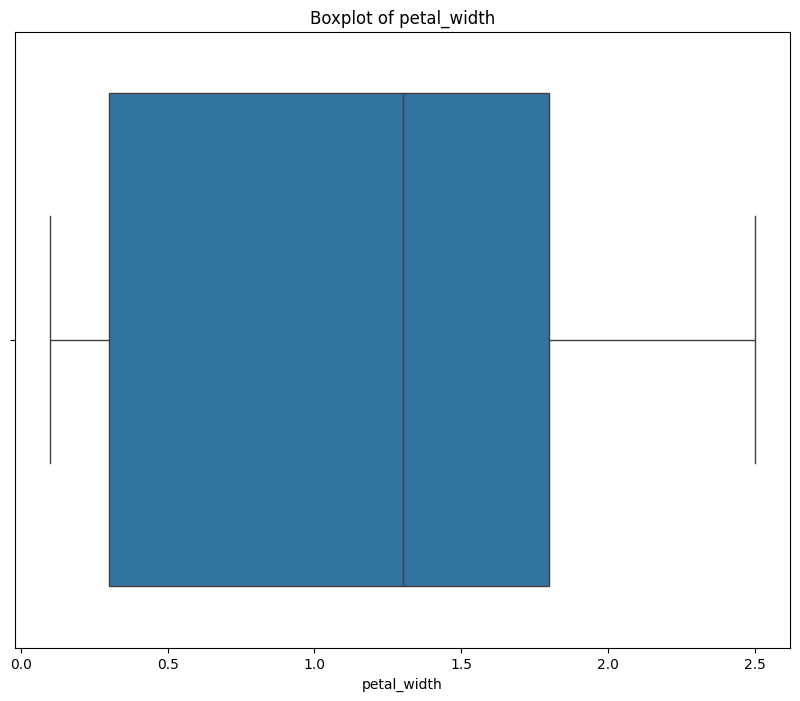

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.drop(columns="species").columns:
  plt.figure(figsize=(10,8))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

In [102]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["species"]=le.fit_transform(df["species"])

In [103]:
df.shape

(143, 5)

In [104]:
x=df.iloc[:,:-1]
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [105]:
y=df.species
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [106]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=41)

In [107]:
from imblearn.over_sampling import SMOTE
sm=SMOTE()
xtrain1,ytrain1=sm.fit_resample(xtrain,ytrain)

In [108]:
ytrain1.value_counts()

,count
species,
0,34
1,34
2,34


In [109]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(xtrain)
xtrain1=scaler.transform(xtrain1)
xtest=scaler.transform(xtest)

In [110]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=30,criterion="entropy",max_depth=3)

In [111]:
# help(rfc)

In [112]:
rfc.fit(xtrain1,ytrain1)

RandomForestClassifier(criterion='entropy', max_depth=3, n_estimators=30)

In [113]:
ypred=rfc.predict(xtest)

In [114]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.9767441860465116

In [115]:
# new prediction
y_new=rfc.predict(scaler.transform([[5.1,3.5,1.4,0.2]]))
y_new

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [116]:
# BOOSTING : XGBOOSTING ALGORITHM
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(xtrain1,ytrain1)
ypred=xgb.predict(xtest)

In [117]:
accuracy_score(ytest,ypred)

0.9767441860465116